# 1st Deep Learning Task - Image Segmentation
By Dominykas Venclovas, LSP nr. - 2425052.

Segmentation of 3 types of images: Bears, Pigs and Rabbits. All data used for this work is obtained from OpenImages V7.

## Start with small dataset and minimalistic model, than move to greater better things
### First of all, setting up and downloading the data

In [4]:
pip install fiftyone

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 161.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 106.3 MB/s eta 

In [2]:
import fiftyone.zoo as foz

dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["segmentations"],
    classes=["Bear", "Pig", "Rabbit"],
    max_samples=100,
)

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [6.3s elapsed, 0s remaining, 981.8Mb/s]       


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [6.3s elapsed, 0s remaining, 981.8Mb/s]       


...

INFO:fiftyone.zoo.datasets:Loading 'open-images-v7' split 'train'


 100% |█████████████████| 100/100 [7.1s elapsed, 0s remaining, 14.3 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 100/100 [7.1s elapsed, 0s remaining, 14.3 samples/s]      


Dataset 'open-images-v7-train-100' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-train-100' created


### Test and visualize the data

In [3]:
# Checking data structure
first_sample = dataset.first()
print(first_sample)

<Sample: {
    'id': '69db3a1f408699731a8248bc',
    'media_type': 'image',
    'filepath': '/root/fiftyone/open-images-v7/train/data/000858e87c40654a.jpg',
    'tags': ['train'],
    'metadata': None,
    'created_at': datetime.datetime(2026, 4, 12, 6, 22, 23, 362000),
    'last_modified_at': datetime.datetime(2026, 4, 12, 6, 22, 23, 362000),
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '69db3a1f408699731a8248ba',
                'attributes': {},
                'tags': [],
                'label': 'Clothing',
                'bounding_box': [0.26625, 0.285833, 0.17625000000000002, 0.65],
                'mask': array([[False, False, False, ..., False, False, False],
                       [False, False, False, ..., False, False, False],
                       [False, False, False, ..., False, False, False],
                       ...,
                       [False, False, False, ..., False, False, False],
                

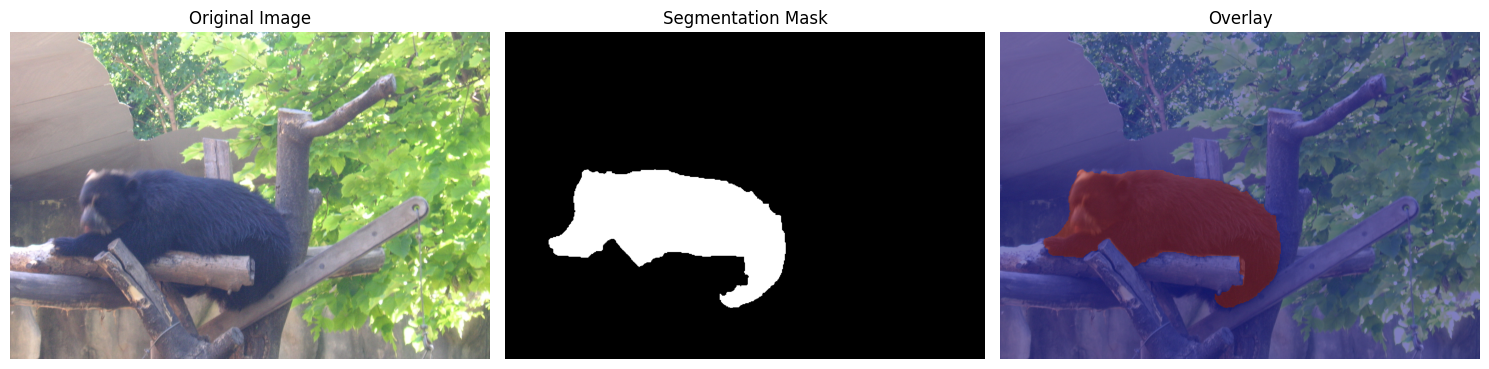

In [4]:
import fiftyone as fo
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Filter to first sample containing a Bear label
bear_view = dataset.filter_labels("ground_truth", fo.ViewField("label") == "Bear")
first_bear = bear_view.first()

# Find the Bear label specifically, image may have multiple classes
bear_detection = next(d for d in first_bear.ground_truth.detections if d.label == "Bear")

# Load image
img = np.array(Image.open(first_bear.filepath))
h, w = img.shape[:2]

# Project local mask to full image size
bbox = bear_detection.bounding_box  # [x, y, w, h] in relative coords
x1, y1 = int(bbox[0] * w), int(bbox[1] * h)
x2, y2 = int((bbox[0] + bbox[2]) * w), int((bbox[1] + bbox[3]) * h)

full_mask = np.zeros((h, w), dtype=bool)
mask_resized = np.array(Image.fromarray(bear_detection.mask).resize(
    (x2 - x1, y2 - y1), Image.NEAREST
))
full_mask[y1:y2, x1:x2] = mask_resized

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(full_mask, cmap="gray")
axes[1].set_title("Segmentation Mask")
axes[1].axis("off")

axes[2].imshow(img)
axes[2].imshow(full_mask, alpha=0.5, cmap="jet")
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Prepare the data (if class is not Bear, Pig or Rabbit, it is the same as background)

In [14]:
import torch
from torch.utils.data import Dataset
import numpy as np
from PIL import Image
from torchvision.transforms.functional import resize as tv_resize
import torchvision.transforms.functional as TF
import random

CLASS_MAP = {
    "Bear":   1,
    "Pig":    2,
    "Rabbit": 3,
    # anything not in this dict is 0
}

IMAGE_SIZE = (256, 256)

class OpenImagesSegDataset(Dataset):
    def __init__(self, fo_dataset, image_size=(256, 256), transform=None):
        self.samples = list(
            fo_dataset.filter_labels(
                "ground_truth",
                fo.ViewField("label").is_in(list(CLASS_MAP.keys()))
            )
        )
        self.image_size = image_size
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = np.array(Image.open(sample.filepath).convert("RGB"))
        h, w = img.shape[:2]

        mask = np.zeros((h, w), dtype=np.int64)

        for det in sample.ground_truth.detections:
            class_idx = CLASS_MAP.get(det.label)
            if class_idx is None:
                continue
            bbox = det.bounding_box
            x1, y1 = int(bbox[0] * w), int(bbox[1] * h)
            x2, y2 = int((bbox[0] + bbox[2]) * w), int((bbox[1] + bbox[3]) * h)
            local_mask = np.array(
                Image.fromarray(det.mask).resize((x2 - x1, y2 - y1), Image.NEAREST)
            )
            mask[y1:y2, x1:x2][local_mask] = class_idx

        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        mask_tensor = torch.tensor(mask, dtype=torch.int64).unsqueeze(0)

        # Resize
        img_tensor = TF.resize(img_tensor, self.image_size, interpolation=TF.InterpolationMode.BILINEAR)
        mask_tensor = TF.resize(mask_tensor, self.image_size, interpolation=TF.InterpolationMode.NEAREST)
        mask_tensor = mask_tensor.squeeze(0)

        if self.transform:
            img_tensor = self.transform(img_tensor)

        # Random horizontal flip
        if random.random() > 0.5:
            img_tensor  = TF.hflip(img_tensor)
            mask_tensor = TF.hflip(mask_tensor.unsqueeze(0)).squeeze(0)

        # Random vertical flip
        if random.random() > 0.5:
            img_tensor  = TF.vflip(img_tensor)
            mask_tensor = TF.vflip(mask_tensor.unsqueeze(0)).squeeze(0)

        return img_tensor, mask_tensor

In [6]:
from torch.utils.data import DataLoader

train_dataset = OpenImagesSegDataset(dataset)
train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True, num_workers=2)

# Sanity check
imgs, masks = next(iter(train_loader))
print(imgs.shape)
print(masks.shape)
print(masks.unique())

torch.Size([20, 3, 256, 256])
torch.Size([20, 256, 256])
tensor([0, 1, 2, 3])


In [15]:
print(len(dataset))
print(dataset.count_values("ground_truth.detections.label"))

100
{'Hamster': 1, 'Bear': 15, 'Goat': 1, 'Human body': 2, 'Koala': 1, 'Dog': 1, 'Bowl': 1, 'Clothing': 2, 'Boy': 1, 'Bird': 4, 'Person': 1, 'Flower': 10, 'Mouse': 3, 'Pig': 55, 'Rabbit': 62, 'Carnivore': 1}


### The model definition



In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    """Two conv layers with BatchNorm and ReLU."""
    def __init__(self, in_channels, out_channels, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SimpleSegNet(nn.Module):
    def __init__(self, num_classes=4):  # background + Bear + Pig + Rabbit
        super().__init__()

        # Encoder (downsampling)
        self.enc1 = ConvBlock(3, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(128, 256)

        # Decoder (upsampling)
        self.dec3 = ConvBlock(256, 128)
        self.dec2 = ConvBlock(128, 64)
        self.dec1 = ConvBlock(64, 32)

        # Final 1x1 conv — outputs one logit map per class
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)           # [8, 32, 256, 256]
        e2 = self.enc2(self.pool(e1))  # [8, 64, 128, 128]
        e3 = self.enc3(self.pool(e2))  # [8, 128, 64, 64]

        # Bottleneck
        b = self.bottleneck(self.pool(e3))  # [8, 256, 32, 32]

        # Decoder
        d3 = self.dec3(F.interpolate(b,  scale_factor=2, mode="bilinear", align_corners=False))
        d2 = self.dec2(F.interpolate(d3, scale_factor=2, mode="bilinear", align_corners=False))
        d1 = self.dec1(F.interpolate(d2, scale_factor=2, mode="bilinear", align_corners=False))

        return self.head(d1)  # [8, 4, 256, 256]


# check
model = SimpleSegNet(num_classes=4)
x = torch.randn(2, 3, 256, 256)
out = model(x)
print(out.shape)

torch.Size([2, 4, 256, 256])


### Model training

In [8]:
from torch.utils.data import DataLoader, random_split

# Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 20
BATCH_SIZE = 8
LR = 1e-3

# Dataset & split
full_dataset = OpenImagesSegDataset(dataset, image_size=(256, 256))
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_set, val_set = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Model, loss, optimizer
model = SimpleSegNet(num_classes=4).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Training loop
for epoch in range(NUM_EPOCHS):

    # Train
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)   # [8, 4, 256, 256]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            outputs = model(imgs)
            val_loss += criterion(outputs, masks).item()

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f}"
    )

# Save
torch.save(model.state_dict(), "simple_seg_net.pth")

Epoch 1/20 | Train Loss: 1.3130 | Val Loss: 1.3831
Epoch 2/20 | Train Loss: 1.0683 | Val Loss: 1.2912
Epoch 3/20 | Train Loss: 0.9387 | Val Loss: 1.2354
Epoch 4/20 | Train Loss: 0.8621 | Val Loss: 1.0555
Epoch 5/20 | Train Loss: 0.8114 | Val Loss: 0.9713
Epoch 6/20 | Train Loss: 0.7759 | Val Loss: 0.8851
Epoch 7/20 | Train Loss: 0.7206 | Val Loss: 0.8193
Epoch 8/20 | Train Loss: 0.6970 | Val Loss: 0.8131
Epoch 9/20 | Train Loss: 0.6762 | Val Loss: 0.7623
Epoch 10/20 | Train Loss: 0.6712 | Val Loss: 0.8014
Epoch 11/20 | Train Loss: 0.6742 | Val Loss: 0.8061
Epoch 12/20 | Train Loss: 0.6455 | Val Loss: 0.9055
Epoch 13/20 | Train Loss: 0.6340 | Val Loss: 0.7378
Epoch 14/20 | Train Loss: 0.6445 | Val Loss: 0.7354
Epoch 15/20 | Train Loss: 0.6202 | Val Loss: 0.7318
Epoch 16/20 | Train Loss: 0.6270 | Val Loss: 0.9215
Epoch 17/20 | Train Loss: 0.6051 | Val Loss: 0.7674
Epoch 18/20 | Train Loss: 0.5987 | Val Loss: 0.7457
Epoch 19/20 | Train Loss: 0.6077 | Val Loss: 0.7362
Epoch 20/20 | Train L

### Testing the model with the test data

In [9]:
import fiftyone.zoo as foz

dataset_test = foz.load_zoo_dataset(
    "open-images-v7",
    split="test",
    label_types=["segmentations"],
    classes=["Bear", "Pig", "Rabbit"],
    max_samples=100,
)

INFO:fiftyone.zoo.datasets:Downloading split 'test' to '/root/fiftyone/open-images-v7/test' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/test/test-images-with-rotation.csv' to '/root/fiftyone/open-images-v7/test/metadata/image_ids.csv'


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v7/test/metadata/classes.csv'


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/classes-segmentation.txt' to '/root/fiftyone/open-images-v7/test/metadata/segmentation_classes.csv'


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/bbox_labels_600_hierarchy.json' to '/tmp/tmpdnyziau_/metadata/hierarchy.json'


...

INFO:fiftyone.zoo.datasets:Loading 'open-images-v7' split 'test'


 100% |█████████████████| 100/100 [6.7s elapsed, 0s remaining, 15.0 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 100/100 [6.7s elapsed, 0s remaining, 15.0 samples/s]      


Dataset 'open-images-v7-test-100' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-test-100' created


In [12]:
# Test if test data is an intended
from torch.utils.data import DataLoader

test_dataset = OpenImagesSegDataset(dataset_test, image_size=(256, 256))
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=True, num_workers=2)

imgs, masks = next(iter(test_loader))
print(imgs.shape)
print(masks.shape)
print(masks.unique())

print(len(dataset_test))
print(dataset_test.count_values("ground_truth.detections.label"))

torch.Size([20, 3, 256, 256])
torch.Size([20, 256, 256])
tensor([0, 1, 2, 3])
100
{'Rabbit': 62, 'Carnivore': 4, 'Pig': 42, 'Hamster': 5, 'Polar bear': 1, 'Raccoon': 1, 'Kangaroo': 2, 'Squirrel': 2, 'Flowerpot': 2, 'Bear': 19, 'Mouse': 3, 'Red panda': 7}


In [25]:
from sklearn.metrics import classification_report, accuracy_score
import torch
import numpy as np
from torch.utils.data import DataLoader

# Load test dataset
test_set = OpenImagesSegDataset(dataset_test, image_size=(256, 256))
test_loader = DataLoader(test_set, batch_size=8, shuffle=False, num_workers=2)

# Collect all predictions and ground truth
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)                          # [8, 4, 256, 256]
        preds = torch.argmax(outputs, dim=1)           # [8, 256, 256]

        all_preds.append(preds.cpu().numpy().flatten())
        all_targets.append(masks.numpy().flatten())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# 0 class is skiped from the evalutation
print(classification_report(
    all_targets,
    all_preds,
    labels=[1, 2, 3],
    target_names=["Bear", "Pig", "Rabbit"],
    zero_division=0
))

# Simple accuracy
overall_acc = accuracy_score(all_targets, all_preds)
print(f"Overall accuracy: {overall_acc:.4f}")

# 0 class is skiped from the evalutation
target_acc = accuracy_score(
    all_targets[all_targets != 0],
    all_preds[all_targets != 0]
    )
print(f"Accuracy (excluding background): {target_acc:.4f}")

              precision    recall  f1-score   support

        Bear       0.00      0.00      0.00    250690
         Pig       0.00      0.00      0.00    601149
      Rabbit       0.40      0.46      0.43   1143178

   micro avg       0.40      0.26      0.32   1995017
   macro avg       0.13      0.15      0.14   1995017
weighted avg       0.23      0.26      0.25   1995017

Overall accuracy: 0.6924
Accuracy (excluding background): 0.2648


Seems that model can only predict two things - background and where a rabbit is located. Pigs and Boar segmentation fails completly

In [27]:
from collections import Counter
import torch

class_counts = Counter()

for _, masks in train_loader:
    flat = masks.numpy().flatten()
    class_counts.update(flat.tolist())

label_names = {0: "Background", 1: "Bear", 2: "Pig", 3: "Rabbit"}
total_pixels = sum(class_counts.values())

for class_idx, name in label_names.items():
    count = class_counts.get(class_idx, 0)
    print(f"{name}: {count:,} pixels ({100 * count / total_pixels:.2f}%)")

print(' ')

sample_counts = Counter()

for _, masks in train_loader:
    for mask in masks:
        for class_idx in mask.unique().tolist():
            sample_counts[class_idx] += 1

for class_idx, name in label_names.items():
    print(f"{name}: {sample_counts.get(class_idx, 0)} samples")

Background: 4,084,817 pixels (77.91%)
Bear: 169,340 pixels (3.23%)
Pig: 285,500 pixels (5.45%)
Rabbit: 703,223 pixels (13.41%)
 
Background: 80 samples
Bear: 13 samples
Pig: 27 samples
Rabbit: 40 samples


Fairly extreme class imbalance and a lot of training may have resulted in model ignoring the smaller classes.

## Model with full dataset

### Data prep

In [8]:
import fiftyone.zoo as foz

dataset_train = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["segmentations"],
    classes=["Bear", "Pig", "Rabbit"],
)

dataset_val = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=["segmentations"],
    classes=["Bear", "Pig", "Rabbit"],
)

print(f"Train samples: {len(dataset_train)}")
print(dataset_train.count_values("ground_truth.detections.label"))

print(f"Validation samples: {len(dataset_val)}")
print(dataset_val.count_values("ground_truth.detections.label"))

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [38.3s elapsed, 0s remaining, 141.8Mb/s]      


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [38.3s elapsed, 0s remaining, 141.8Mb/s]      


...

 100% |█████████████████| 126/126 [4.6s elapsed, 0s remaining, 30.9 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 126/126 [4.6s elapsed, 0s remaining, 30.9 samples/s]      


Dataset 'open-images-v7-validation' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-validation' created


Train samples: 1539
{'Girl': 14, 'Bowl': 2, 'Clothing': 31, 'Bird': 7, 'Flower': 19, 'Chicken': 10, 'Dress': 2, 'Rabbit': 993, 'Bear': 246, 'Hedgehog': 2, 'Frying pan': 1, 'Otter': 1, 'Jeans': 5, 'Toy': 1, 'Wine': 1, 'Carnivore': 29, 'Person': 16, 'Ball': 1, 'Cat': 12, 'Box': 3, 'Goat': 1, 'Dog': 19, 'Mouse': 16, 'Tomato': 1, 'Drink': 1, 'Man': 2, 'Laptop': 1, 'Flowerpot': 3, 'Cattle': 34, 'Tortoise': 1, 'Apple': 1, 'Trousers': 1, 'Bat (Animal)': 1, 'Squirrel': 28, 'Bull': 1, 'Boy': 18, 'Koala': 1, 'Watch': 1, 'Wheel': 3, 'Couch': 2, 'Kangaroo': 4, 'Suit': 1, 'Pig': 1082, 'Human body': 17, 'Car': 2, 'Woman': 2, 'Elephant': 1, 'Sheep': 1, 'Human mouth': 1, 'Sea turtle': 1, 'Carrot': 2, 'Hamster': 23, 'Bottle': 3}
Validation samples: 126
{'Mouse': 3, 'Brown bear': 2, 'Person': 1, 'Pig': 65, 'Squirrel': 3, 'Rabbit': 69, 'Bear': 20, 'Drink': 1, 'Bottle': 2, 'Red panda': 3, 'Polar bear': 2, 'Carnivore': 6, 'Hamster': 1}


In [16]:
from torch.utils.data import DataLoader
import fiftyone as fo

train_set = OpenImagesSegDataset(dataset_train, image_size=(256, 256))
val_set   = OpenImagesSegDataset(dataset_val,   image_size=(256, 256))

train_loader = DataLoader(train_set, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False, num_workers=2)

In [17]:
from collections import Counter

class_counts = Counter()

for _, masks in train_loader:
    flat = masks.numpy().flatten()
    class_counts.update(flat.tolist())

label_names = {0: "Background", 1: "Bear", 2: "Pig", 3: "Rabbit"}
total_pixels = sum(class_counts.values())

for class_idx, name in label_names.items():
    count = class_counts.get(class_idx, 0)
    print(f"{name}: {count:,} pixels ({100 * count / total_pixels:.2f}%)")

print(' ')

sample_counts = Counter()

for _, masks in train_loader:
    for mask in masks:
        for class_idx in mask.unique().tolist():
            sample_counts[class_idx] += 1

for class_idx, name in label_names.items():
    print(f"{name}: {sample_counts.get(class_idx, 0)} samples")

Background: 74,613,862 pixels (73.98%)
Bear: 2,844,025 pixels (2.82%)
Pig: 9,478,934 pixels (9.40%)
Rabbit: 13,923,083 pixels (13.80%)
 
Background: 1539 samples
Bear: 206 samples
Pig: 557 samples
Rabbit: 776 samples


### Training the full model

In [25]:
# Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 40
BATCH_SIZE = 8
LR = 1e-4 # 1e-3

# Model, loss, optimizer
model = SimpleSegNet(num_classes=4).to(DEVICE)
pixel_counts = {
    0: 74_613_862,  # Background
    1:  2_844_025,  # Bear
    2:  9_478_934,  # Pig
    3: 13_923_083,  # Rabbit
}

total = sum(pixel_counts.values())
num_classes = 4

weights = [total / (num_classes * pixel_counts[i]) for i in range(num_classes)]
print(weights)
# [0.338, 8.868, 2.660, 1.811]

weights_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Training loop
for epoch in range(NUM_EPOCHS):

    # Train
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)           # [8, 4, 256, 256]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            outputs = model(imgs)
            val_loss += criterion(outputs, masks).item()

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f}"
    )

# Save
torch.save(model.state_dict(), "full_data_model.pth")

[0.3379395640986925, 8.865947380912615, 2.660106716641344, 1.8110195852455955]
Epoch 1/40 | Train Loss: 1.3360 | Val Loss: 1.2761
Epoch 2/40 | Train Loss: 1.2710 | Val Loss: 1.2301
Epoch 3/40 | Train Loss: 1.2292 | Val Loss: 1.1843
Epoch 4/40 | Train Loss: 1.1981 | Val Loss: 1.1815
Epoch 5/40 | Train Loss: 1.2005 | Val Loss: 1.2087
Epoch 6/40 | Train Loss: 1.1734 | Val Loss: 1.1961
Epoch 7/40 | Train Loss: 1.1665 | Val Loss: 1.1754
Epoch 8/40 | Train Loss: 1.1617 | Val Loss: 1.1640
Epoch 9/40 | Train Loss: 1.1563 | Val Loss: 1.1614
Epoch 10/40 | Train Loss: 1.1478 | Val Loss: 1.1861
Epoch 11/40 | Train Loss: 1.1454 | Val Loss: 1.1553
Epoch 12/40 | Train Loss: 1.1360 | Val Loss: 1.1937
Epoch 13/40 | Train Loss: 1.1200 | Val Loss: 1.1628
Epoch 14/40 | Train Loss: 1.1222 | Val Loss: 1.1667
Epoch 15/40 | Train Loss: 1.1251 | Val Loss: 1.1410
Epoch 16/40 | Train Loss: 1.1232 | Val Loss: 1.1586
Epoch 17/40 | Train Loss: 1.1122 | Val Loss: 1.1424
Epoch 18/40 | Train Loss: 1.1097 | Val Loss: 1

### Testing the full model

In [22]:
import fiftyone.zoo as foz

dataset_test = foz.load_zoo_dataset(
    "open-images-v7",
    split="test",
    label_types=["segmentations"],
    classes=["Bear", "Pig", "Rabbit"],
    max_samples=100,
)


INFO:fiftyone.zoo.datasets:Downloading split 'test' to '/root/fiftyone/open-images-v7/test' if necessary


Necessary images already downloaded


INFO:fiftyone.utils.openimages:Necessary images already downloaded


Existing download of split 'test' is sufficient


INFO:fiftyone.zoo.datasets:Existing download of split 'test' is sufficient


Loading existing dataset 'open-images-v7-test-100'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


INFO:fiftyone.zoo.datasets:Loading existing dataset 'open-images-v7-test-100'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [27]:
from sklearn.metrics import classification_report, accuracy_score
import torch
import numpy as np
from torch.utils.data import DataLoader

# Load test dataset
test_set = OpenImagesSegDataset(dataset_test, image_size=(256, 256))
test_loader = DataLoader(test_set, batch_size=8, shuffle=False, num_workers=2)

# Collect all predictions and ground truth
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)                          # [8, 4, 256, 256]
        preds = torch.argmax(outputs, dim=1)           # [8, 256, 256]

        all_preds.append(preds.cpu().numpy().flatten())
        all_targets.append(masks.numpy().flatten())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# 0 class is skiped from the evalutation
print(classification_report(
    all_targets,
    all_preds,
    labels=[1, 2, 3],
    target_names=["Bear", "Pig", "Rabbit"],
    zero_division=0
))

# Simple accuracy
overall_acc = accuracy_score(all_targets, all_preds)
print(f"Overall accuracy: {overall_acc:.4f}")

# 0 class is skiped from the evalutation
target_acc = accuracy_score(
    all_targets[all_targets != 0],
    all_preds[all_targets != 0]
    )
print(f"Accuracy (excluding background): {target_acc:.4f}")

              precision    recall  f1-score   support

        Bear       0.16      0.56      0.25    250690
         Pig       0.17      0.28      0.21    601149
      Rabbit       0.41      0.48      0.44   1143178

   micro avg       0.27      0.43      0.33   1995017
   macro avg       0.25      0.44      0.30   1995017
weighted avg       0.30      0.43      0.35   1995017

Overall accuracy: 0.6075
Accuracy (excluding background): 0.4273


## Benchmark with the pre-trained model

In [ ]:
# TBD